I've modified the dataset size n because it makes more sense for the task 7 in this way (see below). By the way if you need it as it was, just change it and re-run everything since the code is quite fast besides the first part which takes around 6 hours

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import qiskit
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler, StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM
from qiskit_machine_learning.algorithms import VQC
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN, EffectiveDimension, LocalEffectiveDimension, SamplerQNN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import SPSA
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms.utils import algorithm_globals

2026-07-13 14:09:23.881209: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# DATASETS

In [2]:
# datasets
SEED = 42

# changing it because it requires 4 inputs
X_class, y_class = make_classification(
    n_samples=200,
    n_features=4,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# synthetic dataset
X_s = X_class
y_s = y_class
X_s_tr, X_s_test, y_s_tr, y_s_test = train_test_split(
    X_s,
    y_s,
    test_size=0.4,
    random_state=SEED
)

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_s_tr = scaler.fit_transform(X_s_tr)
X_s_test = scaler.transform(X_s_test)


# this is already present in the full code - TO REMOVE
iris = load_iris(as_frame=True)

X = iris.data       
y = iris.target     

#taking two corresponding labels
mask = y < 2

X_set_vers = X[mask]
y_set_vers = y[mask]

#splitting in training and test
X_train_sv, X_test_sv, y_train_sv, y_test_sv = train_test_split(
    X_set_vers,
    y_set_vers,
    test_size=0.2,
    random_state=42
)

#scaling X datset
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train_sv = scaler.fit_transform(X_train_sv)
X_test_sv = scaler.transform(X_test_sv)


# binary dataset - setosa vs virginica
# already splitted and scaled above
X_b_tr = X_train_sv
X_b_test = X_test_sv
y_b_tr = y_train_sv
y_b_test = y_test_sv

X_b_tr = np.asarray(X_b_tr)
y_b_tr = np.asarray(y_b_tr)

X_b_test = np.asarray(X_b_test)
y_b_test = np.asarray(y_b_test)

# MODELS

In [3]:
'''
UPDATED VERSION OF THE CL MODEL WITH 60 PARAMETERS
'''

def build_model2(input_lenght=4, depth=2, n_class=2):

    model = Sequential()

    model.add(Dense(
        4,
        input_shape=(input_lenght,),
        activation='relu'
    ))

    for _ in range(depth - 1):

        model.add(Dense(
            4,
            activation='relu',
            use_bias=False
        ))

    model.add(Dense(
        n_class,
        activation='softmax',
        use_bias=False
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# defining models
CL_model = build_model2(input_lenght=4, depth=3, n_class=2) 

print(CL_model.count_params())

60


/home/francesco/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


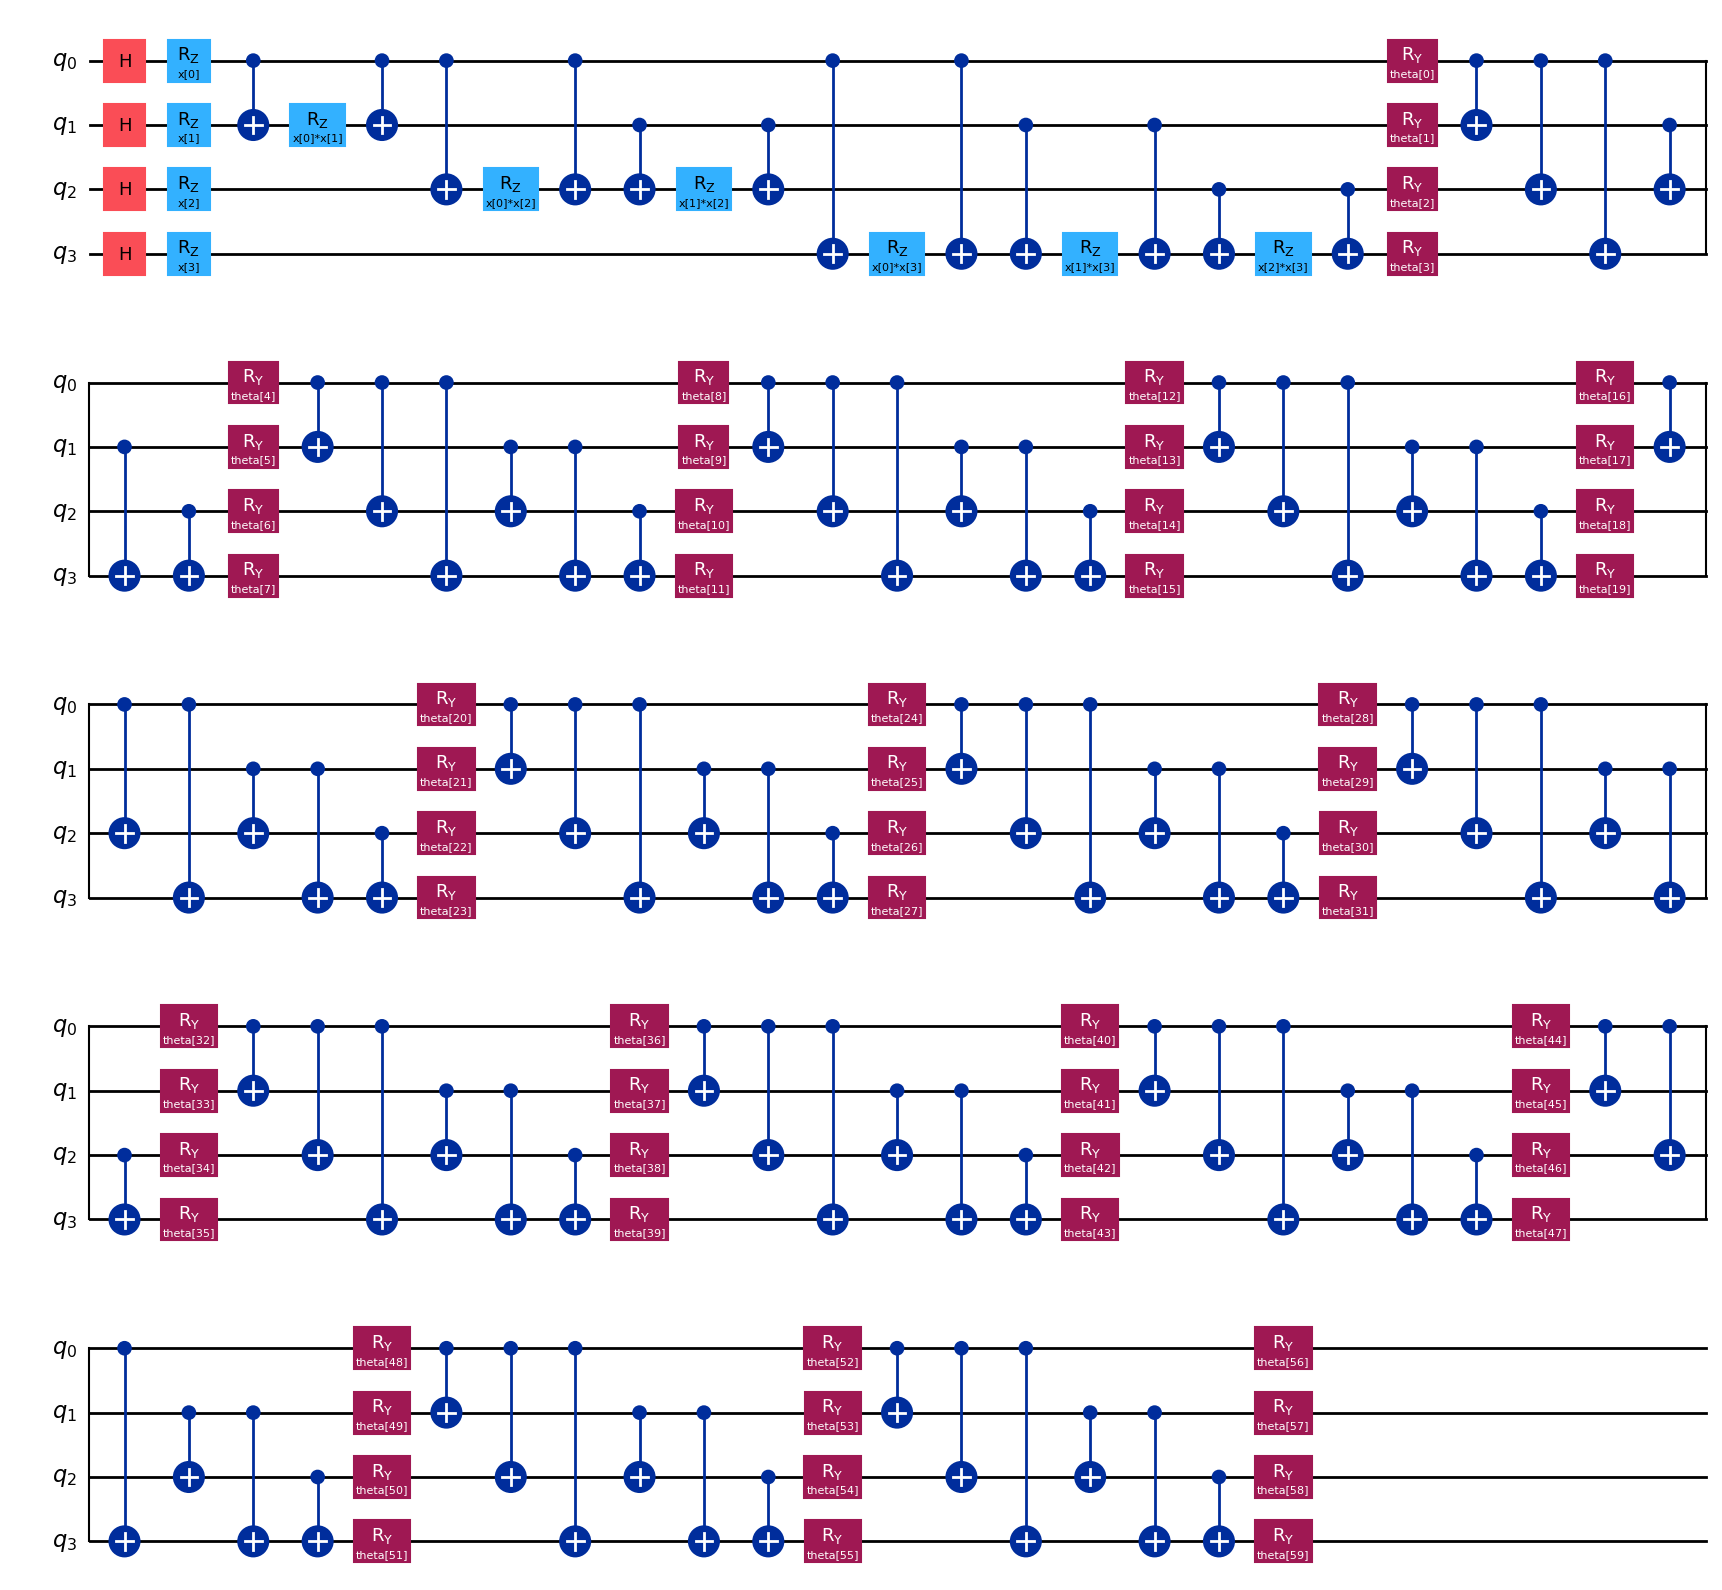

In [4]:
'''
QNN and EASY QNN with 60 parameters
'''

# -----------------------
# Feature Map without entanglement to provide a classical map into a quantum circuit
# -----------------------
def EasyFeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    qc.barrier()
    return qc

# -----------------------
# Feature Map
# -----------------------
def FeatureMap(N):
    x = ParameterVector('x', N)
    qc = QuantumCircuit(N)        
    for i in range(N):
        qc.h(i)
        qc.rz(x[i], i)
    for i in range(N):
        for j in range(i):
            qc.cx(j, i)
            qc.rz(x[j] * x[i], i)
            qc.cx(j, i)
        qc.barrier()
    return qc



# to have a QNN with 60 trainable parameters

def Ansatz_60_par(n_bits):
    theta = ParameterVector('theta', 15*n_bits)
    qc = QuantumCircuit(n_bits)

    for l in range(14):
        for i in range(n_bits):
            qc.ry(theta[i+l*n_bits], i)
        qc.barrier()
    
        for i in range(n_bits-1):
            for j in range(i+1,N):
                qc.cx(i, j)
        qc.barrier()
        
    for i in range(n_bits):    
        qc.ry(theta[i+(l+1)*n_bits], i)
    qc.barrier()

    return qc


#-----------------------
# Parity Interpreter
# ----------------------
def parity(x):
    return "{:b}".format(x).count("1") % 2

def make_sampler_qnn(circ):
    x_p     = sorted([p for p in circ.parameters if p.name.startswith('x')],
                      key=lambda p: p.index)
    theta_p = sorted([p for p in circ.parameters if p.name.startswith('theta')],
                      key=lambda p: p.index)
    return SamplerQNN(
        circuit=circ,
        input_params=x_p,
        weight_params=theta_p,
        interpret=parity,
        output_shape=2,
        sampler=StatevectorSampler(),
    )

# defining models
N = 4
# Creating the Circuits' parts
easy_feature_map = EasyFeatureMap(N)
feature_map = FeatureMap(N)
ansatz      = Ansatz_60_par(N)


qc = feature_map.copy().compose(ansatz.copy())
qc.draw("mpl", style="iqp", plot_barriers=False, filename="circuit.png")

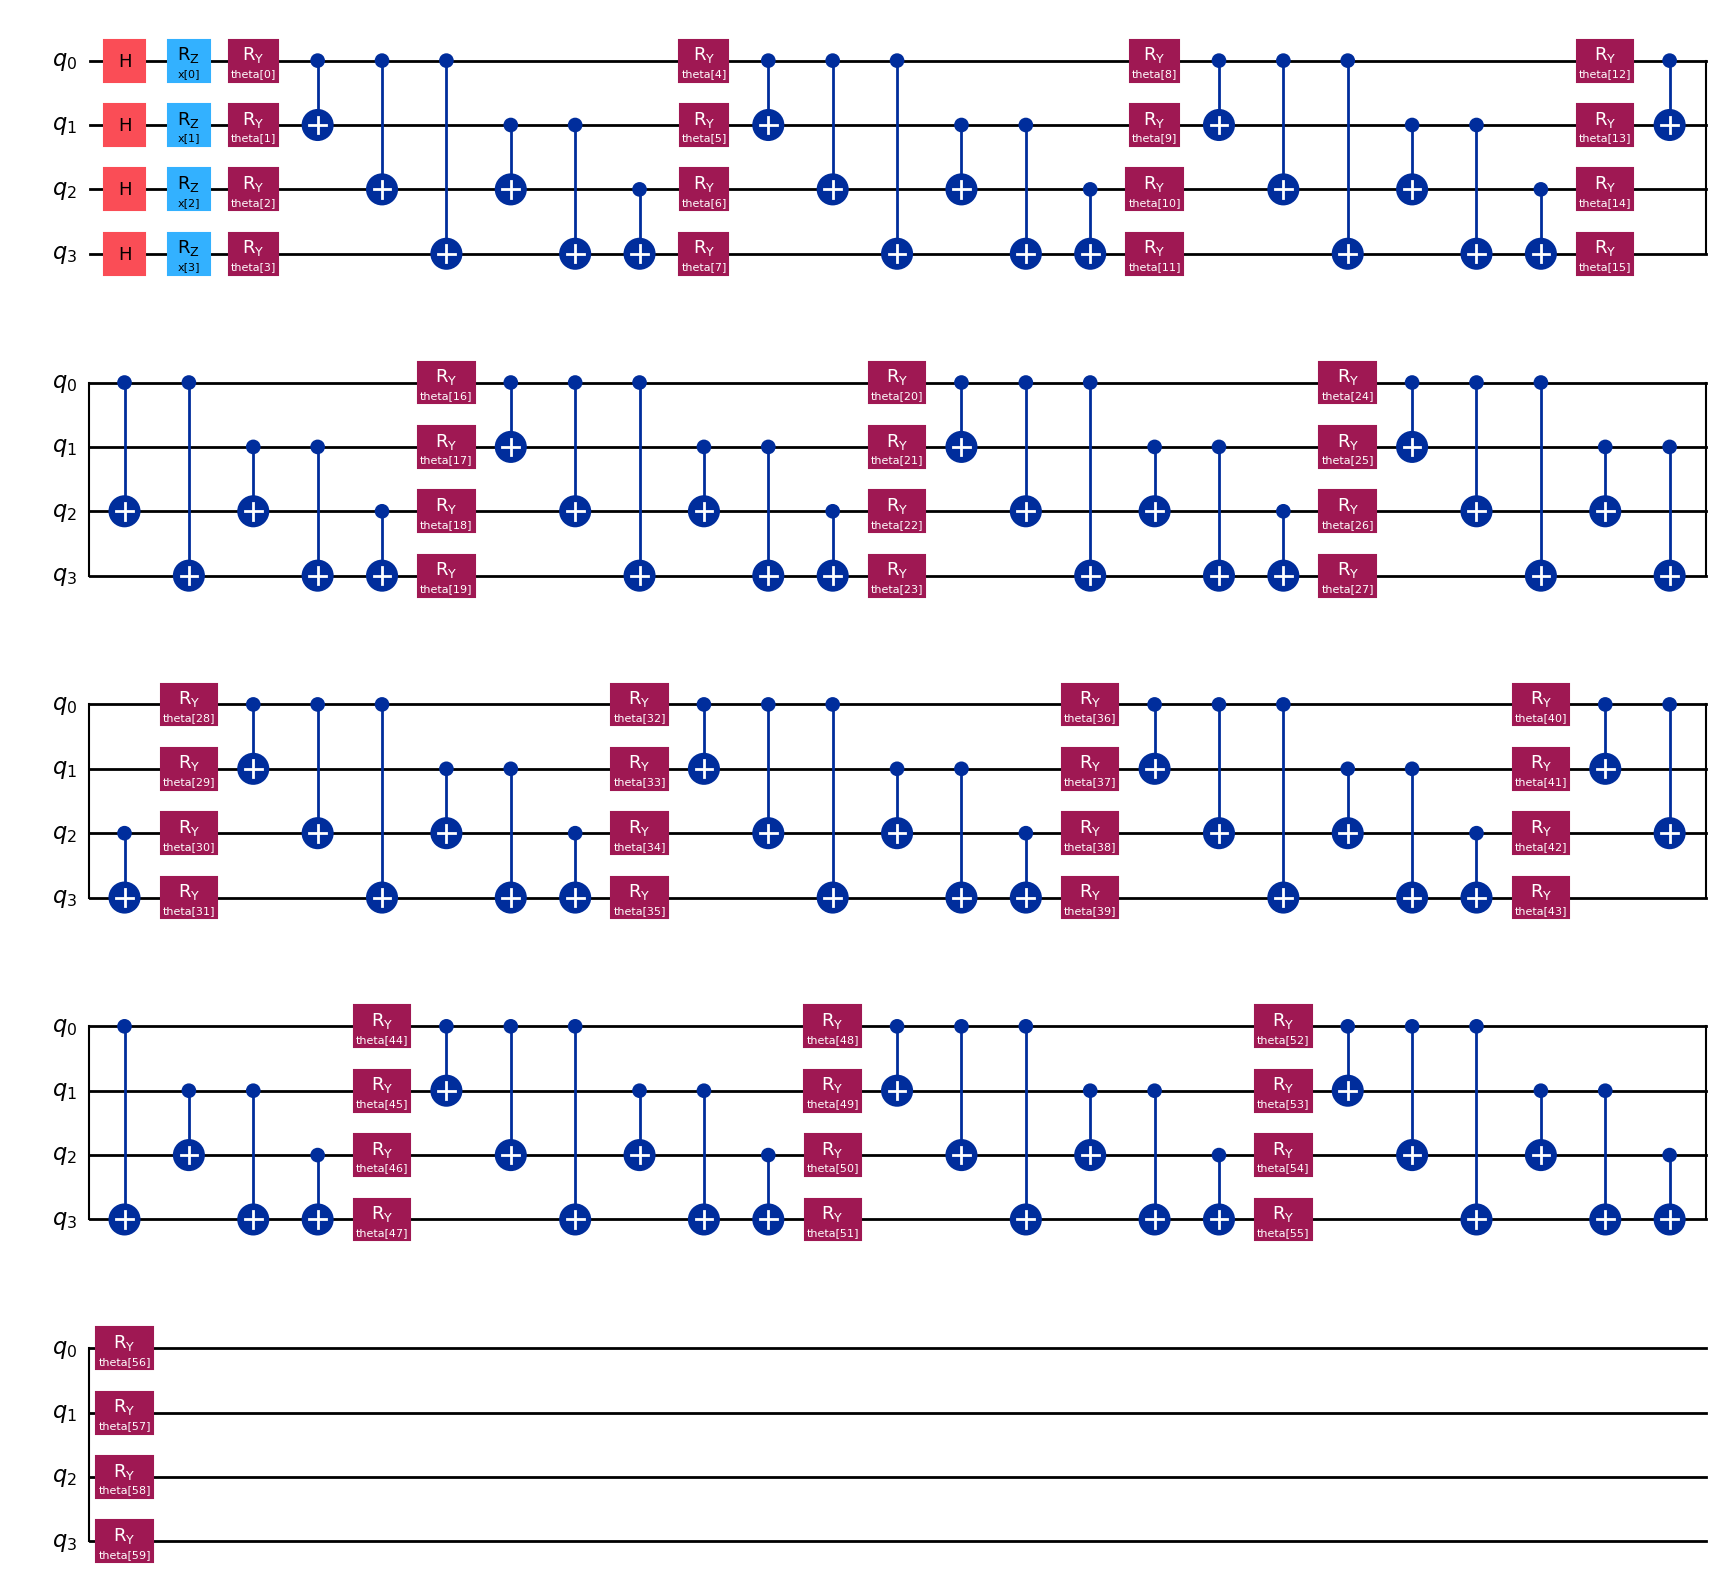

In [5]:
# defining models
# easy quantum model

qc_easy = easy_feature_map.copy().compose(ansatz.copy())
qc_easy.draw("mpl", style="iqp", plot_barriers=False,filename="easy_circuit.png")

# FISHER INFORMATION MATRIX

In [8]:
import pickle

algorithm_globals.random_seed = 42

# Dataset sizes to evaluate ED over (as in the official tutorial)
n = [1000, 3000, 5000, 8000, 10000, 40000, 60000, 100000, 150000, 200000, 500000, 1000000]
# MODIFIED!!!!
# because the old initial size (100) gave bad results and they didn't use it

N = 4
qnn_s = make_sampler_qnn(qc)
qnn_s_easy = make_sampler_qnn(qc_easy)
d = qnn_s.num_weights   
m = qnn_s.num_inputs 
print(f'num_inputs : {m}')
print(f'num_weights: {d}')

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


num_inputs : 4
num_weights: 60


# FOR SYNTHETIC DATASET

In [10]:
# DON'T RUN
'''
# DONE
# ABOUT 6 HOURS

# 2. LOCAL EFFECTIVE DIMENSION FOR QNN AND EASY QNN
# calculated around the space parameter found after training the QNN/easy QNN

# Trained weights: run a quick VQC fit to get trained parameters
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):
    trained_weights_store = []
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

# Training QNNs for local ED
print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap, Ansatz_60_par, N, X_s_tr, y_s_tr)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz_60_par, N, X_s_tr, y_s_tr)

# Local ED — QNN
local_ed_trained_qnn   = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=X_s_tr)

# Local ED — easy QNN
local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=X_s_tr)

local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)

local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)


# save data
with open("object_local_ed_trained_qnn_syn.pkl", "wb") as f:
    pickle.dump(local_ed_trained_qnn, f)

with open("object_local_ed_trained_easy_syn.pkl", "wb") as f:
    pickle.dump(local_ed_trained_easy, f)

with open("local_eff_trained_qnn_syn.pkl", "wb") as f:
    pickle.dump(local_eff_trained_qnn, f)
with open("local_eff_trained_easy_syn.pkl", "wb") as f:
    pickle.dump(local_eff_trained_easy, f)
'''

'\n# DONE\n# ABOUT 6 HOURS\n\n# 2. LOCAL EFFECTIVE DIMENSION FOR QNN AND EASY QNN\n# calculated around the space parameter found after training the QNN/easy QNN\n\n# Trained weights: run a quick VQC fit to get trained parameters\ndef get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):\n    trained_weights_store = []\n    def adam_capture(fun, x0, jac=None, **kwargs):\n        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)\n        def tracked_jac(w):\n            trained_weights_store.append(w.copy())\n            return jac(w)\n        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)\n    vqc = VQC(\n        sampler=StatevectorSampler(),\n        feature_map=feature_map_fn(N),\n        ansatz=ansatz_fn(N),\n        optimizer=adam_capture,\n    )\n    vqc.fit(x_tr, y_tr)\n    return trained_weights_store[-1] if trained_weights_store else vqc.weights\n\n# Training QNNs for local ED\nprint(\'Training QNN for local ED...\')\ntrained_weig

In [11]:
# FISHER INFORMATION FOR QNN AND EASY QNN
# DON'T RUN
'''
# load data
with open("object_local_ed_trained_qnn_syn.pkl", "rb") as f:
    local_eff_trained_qnn = pickle.load(f)

with open("object_local_ed_trained_easy_syn.pkl", "rb") as f:
    local_eff_trained_easy = pickle.load(f)

# compute Fisher information
def compute_fim(ed_obj):
    """Run MC once, return FIM averaged over input samples. Shape: (n_weights, n_weights)"""
    grads, outputs = ed_obj.run_monte_carlo()
    fim = ed_obj.get_fisher_information(grads, outputs)  # (n_samples, n_w, n_w)
    
    return fim.mean(axis=0)                               # (n_w, n_w)

fim_trained_qnn    = compute_fim(local_eff_trained_qnn)

fim_trained_easy   = compute_fim(local_eff_trained_easy)


print(f'FIM trace QNN   trained: {np.trace(fim_trained_qnn):.4f}')

print(f'FIM trace easy   trained: {np.trace(fim_trained_easy):.4f}')


# save Fisher Information
with open("fim_trained_qnn_syn.pkl", "wb") as f:
    pickle.dump(fim_trained_qnn, f)
with open("fim_trained_easy_syn.pkl", "wb") as f:
    pickle.dump(fim_trained_easy, f)
'''

'\n# load data\nwith open("object_local_ed_trained_qnn_syn.pkl", "rb") as f:\n    local_eff_trained_qnn = pickle.load(f)\n\nwith open("object_local_ed_trained_easy_syn.pkl", "rb") as f:\n    local_eff_trained_easy = pickle.load(f)\n\n# compute Fisher information\ndef compute_fim(ed_obj):\n    """Run MC once, return FIM averaged over input samples. Shape: (n_weights, n_weights)"""\n    grads, outputs = ed_obj.run_monte_carlo()\n    fim = ed_obj.get_fisher_information(grads, outputs)  # (n_samples, n_w, n_w)\n\n    return fim.mean(axis=0)                               # (n_w, n_w)\n\nfim_trained_qnn    = compute_fim(local_eff_trained_qnn)\n\nfim_trained_easy   = compute_fim(local_eff_trained_easy)\n\n\nprint(f\'FIM trace QNN   trained: {np.trace(fim_trained_qnn):.4f}\')\n\nprint(f\'FIM trace easy   trained: {np.trace(fim_trained_easy):.4f}\')\n\n\n# save Fisher Information\nwith open("fim_trained_qnn_syn.pkl", "wb") as f:\n    pickle.dump(fim_trained_qnn, f)\nwith open("fim_trained_easy_

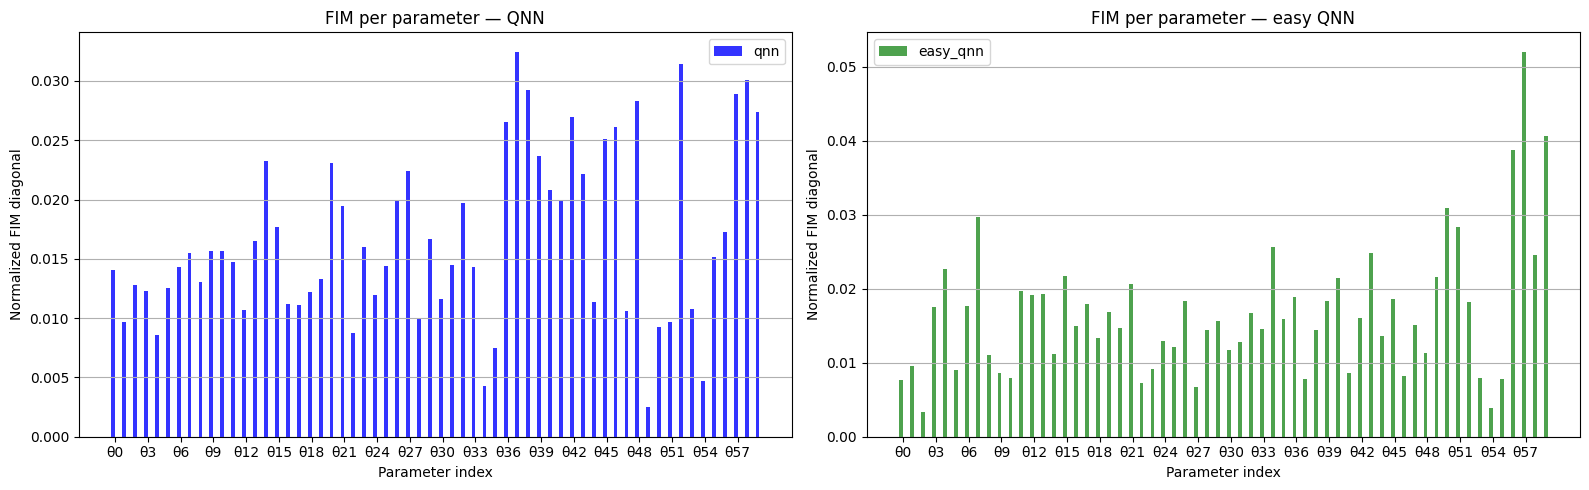

In [12]:
fim_trained_qnn = np.load('fim_trained_qnn_syn.pkl', allow_pickle=True)
fim_trained_easy = np.load('fim_trained_easy_syn.pkl', allow_pickle=True)

# ── Row 2: Fisher Information ─────────────────────────────────
# Autovalori normalizzati per parametro (diagonale della FIM normalizzata)
diag_trained_qnn    = np.diag(fim_trained_qnn)    / np.sum(np.diag(fim_trained_qnn))
#diag_untrained_qnn  = np.diag(fim_untrained_qnn)  / np.sum(np.diag(fim_untrained_qnn))
diag_trained_easy   = np.diag(fim_trained_easy)   / np.sum(np.diag(fim_trained_easy))
#diag_untrained_easy = np.diag(fim_untrained_easy) / np.sum(np.diag(fim_untrained_easy))

x_idx = np.arange(d)
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── QNN ───────────────────────────────────────────────────────
axes[0].bar(x_idx - width/2, diag_trained_qnn,   width, label='qnn',   color='blue',  alpha=0.8)
#axes[1,0].bar(x_idx + width/2, diag_untrained_qnn, width, label='untrained', color='blue',  alpha=0.3)
tick_idx = np.arange(0, d, 3)
axes[0].set_xticks(tick_idx)
axes[0].set_xticklabels([f'θ{i}' for i in tick_idx])
#axes[0].set_xticks(x_idx)
#axes[0].set_xticklabels([f'θ{i}' for i in range(d)])
axes[0].set_xlabel('Parameter index')
axes[0].set_ylabel('Normalized FIM diagonal')
axes[0].set_title('FIM per parameter — QNN')
axes[0].legend()
axes[0].grid(True, axis='y')

# ── easy QNN ──────────────────────────────────────────────────
axes[1].bar(x_idx - width/2, diag_trained_easy,   width, label='easy_qnn',   color='forestgreen', alpha=0.8)
#axes[1,1].bar(x_idx + width/2, diag_untrained_easy, width, label='untrained', color='forestgreen', alpha=0.3)
axes[1].set_xticks(tick_idx)
axes[1].set_xticklabels([f'θ{i}' for i in tick_idx])
axes[1].set_xlabel('Parameter index')
axes[1].set_ylabel('Normalized FIM diagonal')
axes[1].set_title('FIM per parameter — easy QNN')
axes[1].legend()
axes[1].grid(True, axis='y')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig("fim_per_parameter_syn.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

# FOR BINARY DATASET

In [ ]:
# ABOUT 6 HOURS

'''
# ══════════════════════════════════════════════════════════════════════
# 2. LOCAL EFFECTIVE DIMENSION
# calculated around the space parameter found after training the QNN/easy QNN (for trained)
# calculated with random space parameter for not trained QNN/easy QNN
# ══════════════════════════════════════════════════════════════════════

# Trained weights: run a quick VQC fit to get trained parameters
def get_trained_weights(feature_map_fn, ansatz_fn, N, x_tr, y_tr, maxiter=100):
    trained_weights_store = []
    def adam_capture(fun, x0, jac=None, **kwargs):
        opt = ADAM(maxiter=maxiter, lr=0.1, beta_1=0.9, beta_2=0.99, tol=1e-8)
        def tracked_jac(w):
            trained_weights_store.append(w.copy())
            return jac(w)
        return opt.minimize(fun=fun, x0=x0, jac=tracked_jac)
    vqc = VQC(
        sampler=StatevectorSampler(),
        feature_map=feature_map_fn(N),
        ansatz=ansatz_fn(N),
        optimizer=adam_capture,
    )
    vqc.fit(x_tr, y_tr)
    return trained_weights_store[-1] if trained_weights_store else vqc.weights

# Training QNNs for local ED
print('Training QNN for local ED...')
trained_weights_qnn  = get_trained_weights(FeatureMap, Ansatz_60_par, N, X_b_tr, y_b_tr)
print('Training easy QNN for local ED...')
trained_weights_easy = get_trained_weights(EasyFeatureMap, Ansatz_60_par, N, X_b_tr, y_b_tr)

# Local ED — QNN
local_ed_trained_qnn   = LocalEffectiveDimension(qnn=qnn_s,      weight_samples=trained_weights_qnn,  input_samples=X_b_tr)

# Local ED — easy QNN
local_ed_trained_easy   = LocalEffectiveDimension(qnn=qnn_s_easy, weight_samples=trained_weights_easy, input_samples=X_b_tr)


local_eff_trained_qnn    = local_ed_trained_qnn.get_effective_dimension(dataset_size=n)
#local_eff_untrained_qnn  = local_ed_untrained_qnn.get_effective_dimension(dataset_size=n)
local_eff_trained_easy   = local_ed_trained_easy.get_effective_dimension(dataset_size=n)
#local_eff_untrained_easy = local_ed_untrained_easy.get_effective_dimension(dataset_size=n)

with open("object_local_ed_trained_qnn_bin.pkl", "wb") as f:
    pickle.dump(local_ed_trained_qnn, f)

with open("object_local_ed_trained_easy_bin.pkl", "wb") as f:
    pickle.dump(local_ed_trained_easy, f)

with open("local_eff_trained_qnn_bin.pkl", "wb") as f:
    pickle.dump(local_eff_trained_qnn, f)
with open("local_eff_trained_easy_bin.pkl", "wb") as f:
    pickle.dump(local_eff_trained_easy, f)
'''

In [ ]:
# FISHER INFORMATION FOR QNN AND EASY QNN
'''
# load data
with open("object_local_ed_trained_qnn_bin.pkl", "rb") as f:
    local_eff_trained_qnn = pickle.load(f)

with open("object_local_ed_trained_easy_bin.pkl", "rb") as f:
    local_eff_trained_easy = pickle.load(f)

# compute Fisher information
def compute_fim(ed_obj):
    """Run MC once, return FIM averaged over input samples. Shape: (n_weights, n_weights)"""
    grads, outputs = ed_obj.run_monte_carlo()
    fim = ed_obj.get_fisher_information(grads, outputs)  # (n_samples, n_w, n_w)
    
    return fim.mean(axis=0)                               # (n_w, n_w)

fim_trained_qnn    = compute_fim(local_eff_trained_qnn)

fim_trained_easy   = compute_fim(local_eff_trained_easy)


print(f'FIM trace QNN   trained: {np.trace(fim_trained_qnn):.4f}')

print(f'FIM trace easy   trained: {np.trace(fim_trained_easy):.4f}')


# save Fisher Information
with open("fim_trained_qnn_bin.pkl", "wb") as f:
    pickle.dump(fim_trained_qnn, f)
with open("fim_trained_easy_bin.pkl", "wb") as f:
    pickle.dump(fim_trained_easy, f)
'''

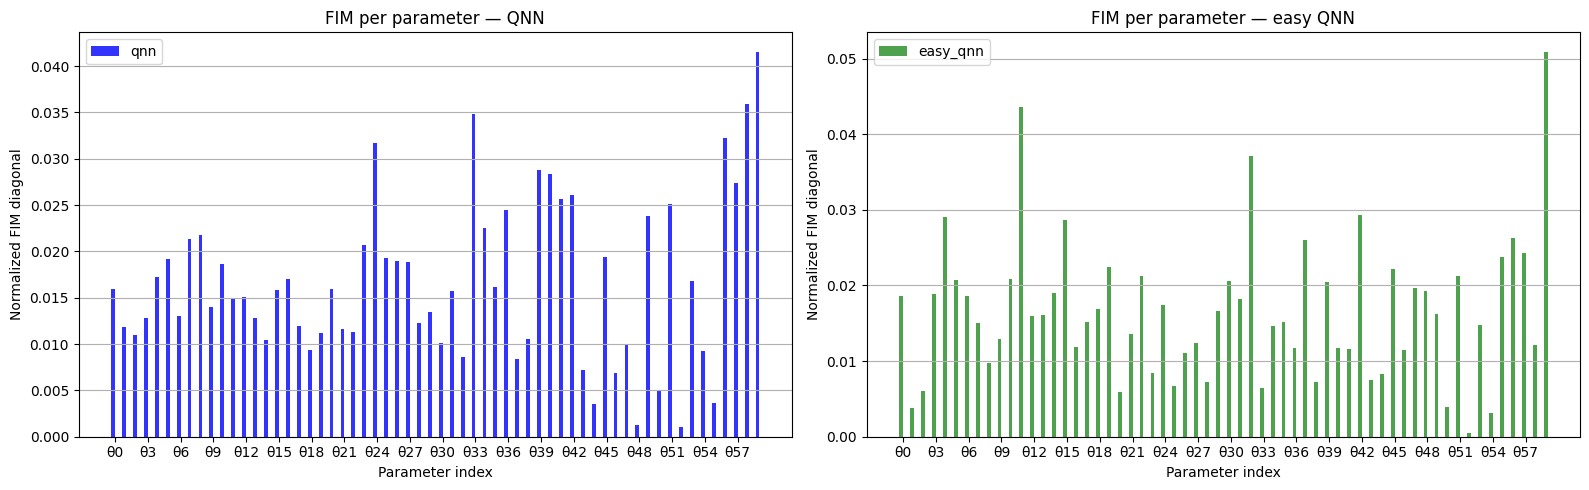

In [9]:
fim_trained_qnn = np.load('fim_trained_qnn_bin.pkl', allow_pickle=True)
fim_trained_easy = np.load('fim_trained_easy_bin.pkl', allow_pickle=True)

# ── Row 2: Fisher Information ─────────────────────────────────
# Autovalori normalizzati per parametro (diagonale della FIM normalizzata)
diag_trained_qnn    = np.diag(fim_trained_qnn)    / np.sum(np.diag(fim_trained_qnn))
#diag_untrained_qnn  = np.diag(fim_untrained_qnn)  / np.sum(np.diag(fim_untrained_qnn))
diag_trained_easy   = np.diag(fim_trained_easy)   / np.sum(np.diag(fim_trained_easy))
#diag_untrained_easy = np.diag(fim_untrained_easy) / np.sum(np.diag(fim_untrained_easy))

x_idx = np.arange(d)
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── QNN ───────────────────────────────────────────────────────
axes[0].bar(x_idx - width/2, diag_trained_qnn,   width, label='qnn',   color='blue',  alpha=0.8)
#axes[1,0].bar(x_idx + width/2, diag_untrained_qnn, width, label='untrained', color='blue',  alpha=0.3)
tick_idx = np.arange(0, d, 3)
axes[0].set_xticks(tick_idx)
axes[0].set_xticklabels([f'θ{i}' for i in tick_idx])
#axes[0].set_xticks(x_idx)
#axes[0].set_xticklabels([f'θ{i}' for i in range(d)])
axes[0].set_xlabel('Parameter index')
axes[0].set_ylabel('Normalized FIM diagonal')
axes[0].set_title('FIM per parameter — QNN')
axes[0].legend()
axes[0].grid(True, axis='y')

# ── easy QNN ──────────────────────────────────────────────────
axes[1].bar(x_idx - width/2, diag_trained_easy,   width, label='easy_qnn',   color='forestgreen', alpha=0.8)
#axes[1,1].bar(x_idx + width/2, diag_untrained_easy, width, label='untrained', color='forestgreen', alpha=0.3)
axes[1].set_xticks(tick_idx)
axes[1].set_xticklabels([f'θ{i}' for i in tick_idx])
axes[1].set_xlabel('Parameter index')
axes[1].set_ylabel('Normalized FIM diagonal')
axes[1].set_title('FIM per parameter — easy QNN')
axes[1].legend()
axes[1].grid(True, axis='y')

# Adjust layout
plt.tight_layout()

# Save the figure
plt.savefig("fim_per_parameter_bin.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()

# FILES
- object_local_ed_trained_qnn_syn.pkl
- object_local_ed_trained_easy_syn.pkl
- local_eff_trained_qnn_syn.pkl
- local_eff_trained_easy_syn.pkl
- fim_trained_qnn_syn.pkl
- fim_trained_easy_syn.pkl

- object_local_ed_trained_qnn_bin.pkl
- object_local_ed_trained_easy_bin.pkl
- local_eff_trained_qnn_bin.pkl
- local_eff_trained_easy_bin.pkl
- fim_trained_qnn_bin.pkl
- fim_trained_easy_bin.pkl